In [1]:
import json
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})

REPORT_DIR = os.path.join('..', 'evaluation', 'reports')
with open(os.path.join(REPORT_DIR, 'comparative_analysis.json')) as f:
    data = json.load(f)

agents_data = data['ranked_agents']
agent_names = [a['agent'] for a in agents_data]

print('Agents (ranked by success rate):', agent_names)

Agents (ranked by success rate): ['DQN', 'Rule-Based', 'Bandit', 'RetrievalOnly', 'Random']


## 1 — Success Rate

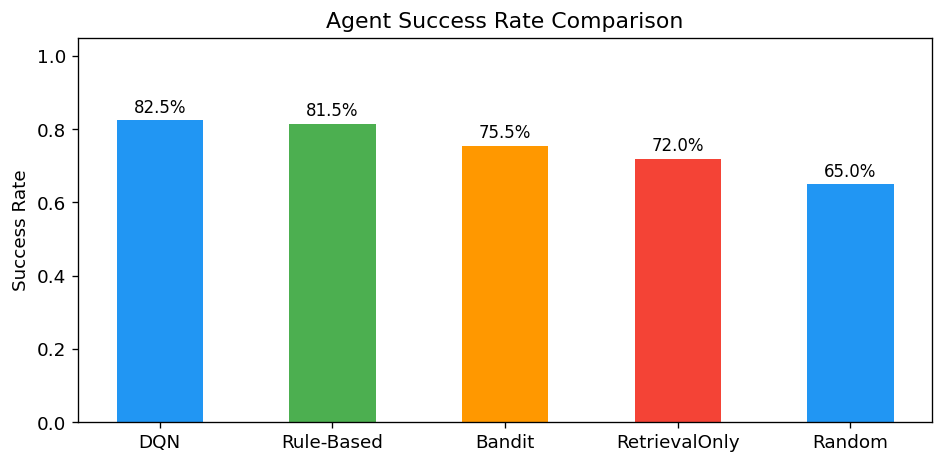

In [2]:
success_rates = [a['success_rate'] for a in agents_data]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(agent_names, success_rates, color=colors[:len(agent_names)], width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Success Rate')
ax.set_title('Agent Success Rate Comparison')
for bar, val in zip(bars, success_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 2 — Average Reward

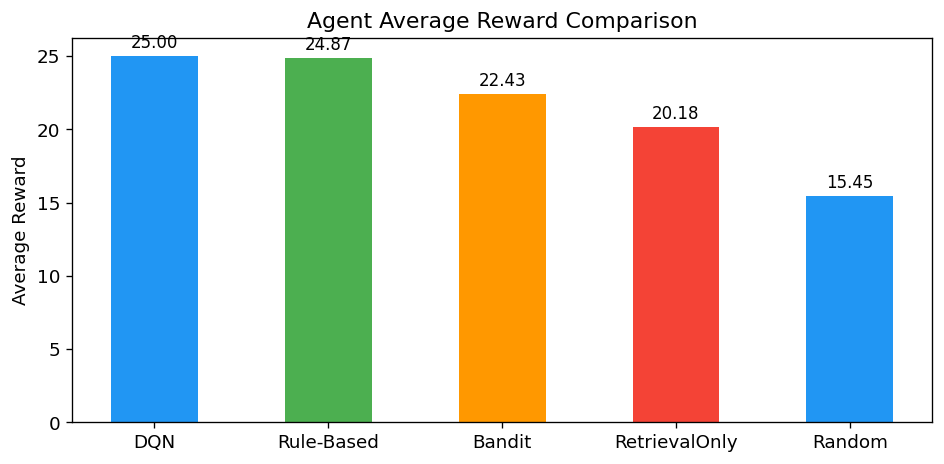

In [3]:
avg_rewards = [a['avg_reward'] for a in agents_data]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(agent_names, avg_rewards, color=colors[:len(agent_names)], width=0.5)
ax.set_ylabel('Average Reward')
ax.set_title('Agent Average Reward Comparison')
for bar, val in zip(bars, avg_rewards):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 3 — Average Steps per Episode

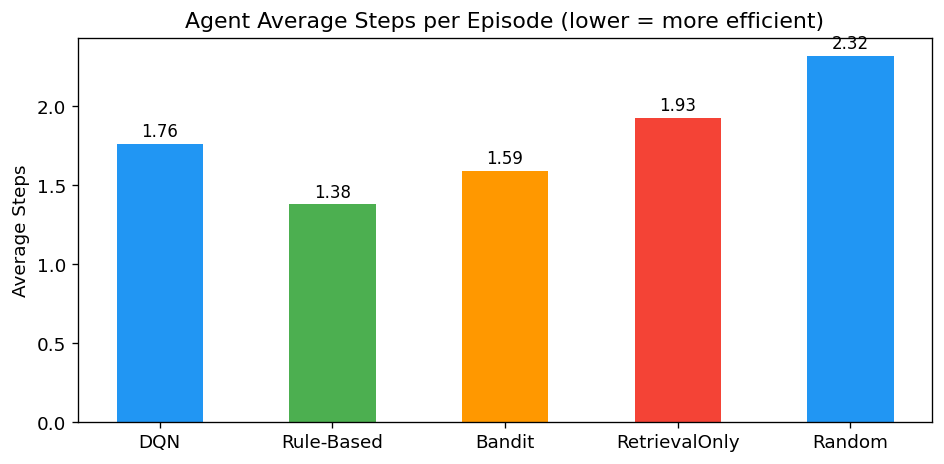

In [4]:
avg_steps = [a['avg_steps'] for a in agents_data]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(agent_names, avg_steps, color=colors[:len(agent_names)], width=0.5)
ax.set_ylabel('Average Steps')
ax.set_title('Agent Average Steps per Episode (lower = more efficient)')
for bar, val in zip(bars, avg_steps):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 4 — Frustration Delta (cumulative per episode)

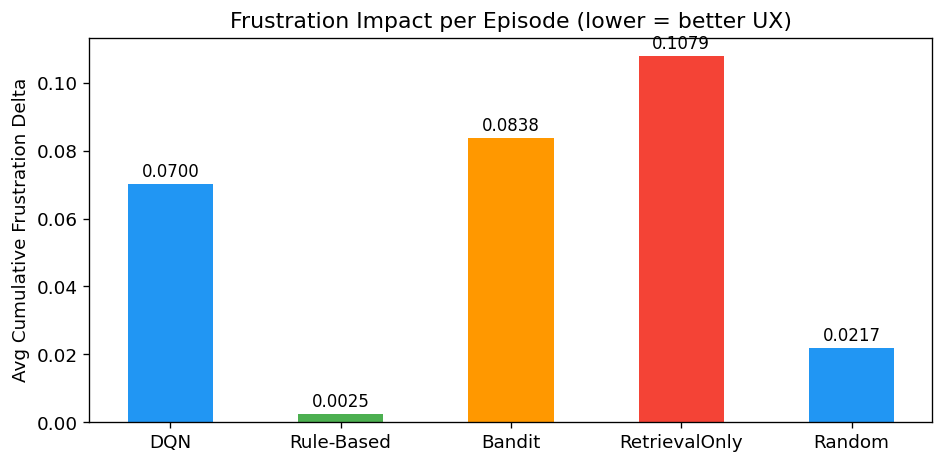

In [5]:
frustration = [a['frustration_delta'] for a in agents_data]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(agent_names, frustration, color=colors[:len(agent_names)], width=0.5)
ax.set_ylabel('Avg Cumulative Frustration Delta')
ax.set_title('Frustration Impact per Episode (lower = better UX)')
for bar, val in zip(bars, frustration):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 5 — Strategy Distribution (grouped bar chart)

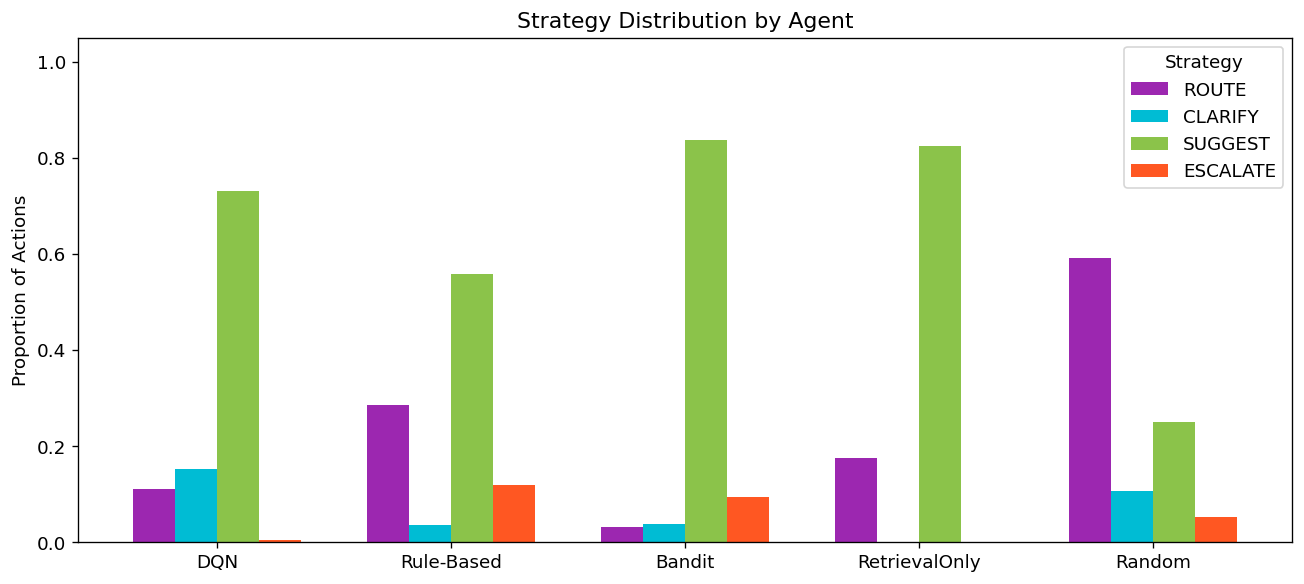

In [6]:
strategies = ['ROUTE', 'CLARIFY', 'SUGGEST', 'ESCALATE']
strat_colors = ['#9C27B0', '#00BCD4', '#8BC34A', '#FF5722']

x = np.arange(len(agent_names))
n_strats = len(strategies)
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
for i, (strat, col) in enumerate(zip(strategies, strat_colors)):
    vals = [a['strategy_distribution'].get(strat, 0.0) for a in agents_data]
    offset = (i - n_strats / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=strat, color=col)

ax.set_xticks(x)
ax.set_xticklabels(agent_names)
ax.set_ylabel('Proportion of Actions')
ax.set_title('Strategy Distribution by Agent')
ax.legend(title='Strategy')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Analysis

### Why DQN Performs Best

DQN is the only **learning-based** agent in this comparison. It trains a neural network to map the full 37-dimensional state vector to Q-values, discovering which action yields the highest long-run reward from any given context. Key advantages:

- **Temporal credit assignment** — DQN learns that early clarification leads to higher suggest success later, even when the immediate reward is negative.
- **Context sensitivity** — Every feature (similarity, frustration, SLA remaining, entity completeness) influences the action choice, not just one threshold.
- **Exploration during training** — Epsilon-greedy exploration lets the agent discover non-obvious strategies that rigid rules miss.

### Differences between agent types

| Agent | Type | Strength | Weakness |
|---|---|---|---|
| **DQN** | Learning-based | Full-context, optimal long-run policy | Requires training data and compute |
| **Rule-Based** | Heuristic | Transparent, consistent, zero training | Fixed rules break on edge cases |
| **RetrievalOnly** | Retrieval-based | Simple, directly tied to KB coverage | Ignores frustration, SLA, clarification need |
| **Random** | Stochastic | Unbiased lower bound | No strategy whatsoever |

### Improvement Summary

DQN's lead over Random is the most significant — roughly **+26–27 pp** in success rate — demonstrating that random action selection is catastrophically inefficient in this task. Its advantage over Rule-Based is smaller but consistent, showing that learned policies squeeze out edge-case improvements that static heuristics cannot. RetrievalOnly sits between the two: it has domain signal (similarity) but discards the rest of the state.